# 15 · Deep learning with PyTorch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/15_pytorch_deep_learning.ipynb)

PyTorch is the library most deep-learning research and industry work uses. In notebook 09 you wrote
backpropagation by hand; PyTorch does that part automatically (**autograd**) and runs on a GPU.

You will (1) see autograd reproduce your hand-derived gradient, (2) train a neural network for loan default
with a proper training loop, validation and early stopping, and (3) train an **LSTM** sequence model to forecast
NYSE trading volume and compare it with the linear model from project 12.

**In Colab:** *Runtime → Change runtime type → T4 GPU* makes training faster, but everything here also runs on CPU.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
import torch
from torch import nn
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.14.1+cu130 | device: cpu


## 1. Tensors and autograd
A tensor is a NumPy array that can live on a GPU and remember how it was computed. Call `.backward()` on a result and PyTorch fills in the gradient of every input marked `requires_grad=True`.

In [3]:
df = pd.read_csv(DATA + "factor_returns.csv")
Xnp = np.column_stack([np.ones(len(df)), df[["mkt_excess", "smb", "hml", "mom"]].to_numpy()])
ynp = df["fund_excess"].to_numpy()
X = torch.tensor(Xnp, dtype=torch.float64); yt = torch.tensor(ynp, dtype=torch.float64)
manual_grad = 2 / len(ynp) * Xnp.T @ (Xnp @ np.array([0.1, 1.0, 0.5, 0.3, 0.0]) - ynp)   # the formula from notebook 09
print("manual gradient:", manual_grad.round(4))

manual gradient: [-0.1304 -0.1353  1.0528 -0.8824  0.2574]


### Exercise 1

Create `b = torch.tensor([0.1, 1.0, 0.5, 0.3, 0.0], dtype=torch.float64, requires_grad=True)`, compute the MSE loss `((X @ b - yt) ** 2).mean()`, call `.backward()`, and store `b.grad` in `grad_autograd`. It should equal `manual_grad`.

In [4]:
# Your code here

In [5]:
check("15.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 15.1: not answered yet. Store your answer in `grad_autograd`.


## 2. The training loop: OLS the PyTorch way
Every PyTorch model is trained with the same five lines: predict, compute loss, zero old gradients, backpropagate, step.

In [6]:
Xs = torch.tensor((Xnp[:, 1:] - Xnp[:, 1:].mean(0)) / Xnp[:, 1:].std(0), dtype=torch.float32)
ys = torch.tensor(ynp, dtype=torch.float32).unsqueeze(1)
lin = nn.Linear(4, 1)
opt = torch.optim.SGD(lin.parameters(), lr=0.1)
for epoch in range(300):
    pred = lin(Xs)                         # 1. forward pass
    loss = nn.functional.mse_loss(pred, ys)   # 2. loss
    opt.zero_grad()                        # 3. clear old gradients
    loss.backward()                        # 4. backpropagation (autograd)
    opt.step()                             # 5. update weights
ols = np.linalg.lstsq(np.column_stack([np.ones(len(ynp)), Xs.numpy()]), ynp, rcond=None)[0]
print("PyTorch:", np.r_[lin.bias.item(), lin.weight.detach().numpy().ravel()].round(4)); print("OLS:    ", ols.round(4))

PyTorch: [ 0.6893  3.4261  1.0981  1.0541 -0.0129]
OLS:     [ 0.6893  3.4261  1.0981  1.0541 -0.0129]


## 3. A neural network for loan default
Now a real model: standardised features, a train/validation/test split, mini-batches, dropout, weight decay, and **early stopping** (stop when validation loss stops improving, keep the best weights).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from torch.utils.data import TensorDataset, DataLoader

cr = pd.read_csv(DATA + "credit_default.csv")
Xc = pd.get_dummies(cr.drop(columns="default"), columns=["purpose"], drop_first=True, dtype=float)
yc = cr["default"].to_numpy()
X_tmp, X_te, y_tmp, y_te = train_test_split(Xc, yc, test_size=0.25, random_state=0, stratify=yc)
X_tr, X_va, y_tr, y_va = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=0, stratify=y_tmp)
sc = StandardScaler().fit(X_tr)                                   # fit scaling on training data only
to_t = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)
Xtr_t, Xva_t, Xte_t = to_t(sc.transform(X_tr)), to_t(sc.transform(X_va)), to_t(sc.transform(X_te))
ytr_t, yva_t = to_t(y_tr).unsqueeze(1), to_t(y_va).unsqueeze(1)
print("features:", Xc.shape[1], "| train / validation / test:", len(X_tr), len(X_va), len(X_te))

features: 9 | train / validation / test: 480 120 200


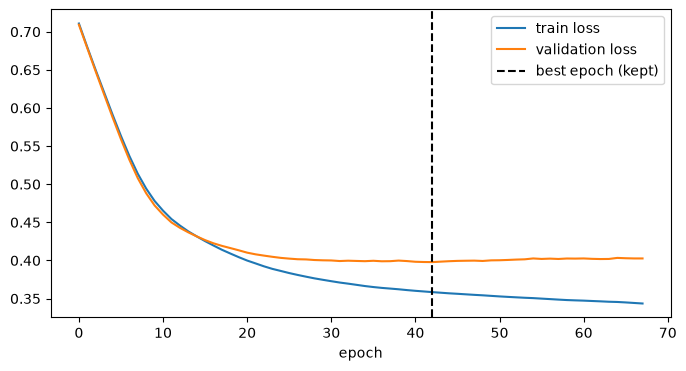

test AUC  neural net 0.831 | logistic regression 0.838


In [8]:
def make_net(n_in, hidden=(32, 16), dropout=0.2):
    layers, d = [], n_in
    for h in hidden:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        d = h
    layers.append(nn.Linear(d, 1))                 # one output: the log-odds of default
    return nn.Sequential(*layers)

def train(model, epochs=300, lr=1e-3, weight_decay=1e-4, patience=25, batch=64):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()              # sigmoid + log-loss in one numerically stable step
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)
    best, best_state, wait, hist = np.inf, None, 0, []
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr_loss = loss_fn(model(Xtr_t.to(device)), ytr_t.to(device)).item()
            va_loss = loss_fn(model(Xva_t.to(device)), yva_t.to(device)).item()
        hist.append((tr_loss, va_loss))
        if va_loss < best - 1e-4:
            best, wait = va_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, np.array(hist)

torch.manual_seed(0)
net, hist = train(make_net(Xc.shape[1]))
plt.plot(hist[:, 0], label="train loss"); plt.plot(hist[:, 1], label="validation loss")
plt.axvline(hist[:, 1].argmin(), color="k", ls="--", label="best epoch (kept)"); plt.xlabel("epoch"); plt.legend(); plt.show()

net.eval()
with torch.no_grad():
    p_net = torch.sigmoid(net(Xte_t.to(device))).cpu().numpy().ravel()
p_lr = LogisticRegression(max_iter=1000).fit(sc.transform(X_tr), y_tr).predict_proba(sc.transform(X_te))[:, 1]
print(f"test AUC  neural net {roc_auc_score(y_te, p_net):.3f} | logistic regression {roc_auc_score(y_te, p_lr):.3f}")

On small tabular data, a neural network rarely beats logistic regression or gradient boosting by much. Deep learning shines with large data and unstructured inputs: sequences, text, images.

### Exercise 2

Build `model = make_net(9, hidden=(32, 16))` and count its trainable parameters (weights + biases). Store the number in `n_params`.

<details><summary>Hint</summary>

`sum(p.numel() for p in model.parameters())`

</details>

In [9]:
# Your code here

In [10]:
check("15.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 15.2: not answered yet. Store your answer in `n_params`.


## 4. A sequence model: LSTM for next-day trading volume
An LSTM reads the last 20 days in order and keeps a memory of what it has seen. We use the real NYSE data from project 12 and the same rules: features only up to yesterday, train before 1980, test after.

In [11]:
import subprocess, sys
from pathlib import Path
try:
    import ISLP
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "ISLP"], check=True)
    import ISLP
nyse = pd.read_csv(Path(ISLP.__file__).parent / "data" / "NYSE.csv")
cols = ["log_volume", "DJ_return", "log_volatility"]
train_mask = nyse["train"].to_numpy()
mu, sd = nyse.loc[train_mask, cols].mean(), nyse.loc[train_mask, cols].std()   # scale with training stats only
Z = ((nyse[cols] - mu) / sd).to_numpy(dtype=np.float32)
LOOKBACK = 20
seqs = np.stack([Z[t - LOOKBACK:t] for t in range(LOOKBACK, len(Z))])          # days t-20 ... t-1
target = nyse["log_volume"].to_numpy(dtype=np.float32)[LOOKBACK:]               # day t
is_tr = train_mask[LOOKBACK:]
S_tr, S_te, t_tr, t_te = map(torch.tensor, (seqs[is_tr], seqs[~is_tr], target[is_tr], target[~is_tr]))
print("sequences:", tuple(seqs.shape), "→ (samples, days, features) | train", len(S_tr), "test", len(S_te))

sequences: (6031, 20, 3) → (samples, days, features) | train 4261 test 1770


In [12]:
class VolumeLSTM(nn.Module):
    def __init__(self, n_features=3, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1]).squeeze(-1)        # use the memory after the last day

torch.manual_seed(0)
lstm = VolumeLSTM().to(device)
opt = torch.optim.Adam(lstm.parameters(), lr=3e-3)
n_val = len(S_tr) // 5                                        # last 20% of training period for validation (time order kept)
S_fit, t_fit, S_val, t_val = S_tr[:-n_val], t_tr[:-n_val], S_tr[-n_val:], t_tr[-n_val:]
loader = DataLoader(TensorDataset(S_fit, t_fit), batch_size=128, shuffle=True)   # shuffling sequences is fine: each holds its own past
best, best_state = np.inf, None
for ep in range(25):
    lstm.train()
    for xb, yb in loader:
        opt.zero_grad(); loss = nn.functional.mse_loss(lstm(xb.to(device)), yb.to(device)); loss.backward(); opt.step()
    lstm.eval()
    with torch.no_grad():
        v = nn.functional.mse_loss(lstm(S_val.to(device)), t_val.to(device)).item()
    if v < best:
        best, best_state = v, {k: x.detach().clone() for k, x in lstm.state_dict().items()}
lstm.load_state_dict(best_state); lstm.eval()
with torch.no_grad():
    pred = lstm(S_te.to(device)).cpu().numpy()

from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
flat = seqs.reshape(len(seqs), -1)                            # same 20-day window, fed to a linear model
ridge = RidgeCV(alphas=np.logspace(-2, 3, 11)).fit(flat[is_tr], target[is_tr])
print(f"test R²  LSTM {r2_score(t_te.numpy(), pred):.3f} | ridge on the same 20-day window {r2_score(target[~is_tr], ridge.predict(flat[~is_tr])):.3f}")

test R²  LSTM 0.418 | ridge on the same 20-day window 0.417


A well-regularised linear model is a strong benchmark for financial time series, and often hard to beat.
The LSTM earns its keep when there is a lot of data and genuinely non-linear, long-memory structure.

**Your turn (no checker):** try `LOOKBACK = 60`, a bigger `hidden` size, or add day-of-week as a fourth feature.
Does test R² improve, and is the gain larger than what you get from re-running with another seed?

---
## Solutions

In [13]:
b = torch.tensor([0.1, 1.0, 0.5, 0.3, 0.0], dtype=torch.float64, requires_grad=True)
loss = ((X @ b - yt) ** 2).mean(); loss.backward()
grad_autograd = b.grad; print("1) autograd:", grad_autograd.numpy().round(4))
model = make_net(9, hidden=(32, 16))
n_params = sum(p.numel() for p in model.parameters()); print("2) parameters:", n_params, "= (9·32+32) + (32·16+16) + (16·1+1)")
check_all("15")

1) autograd: [-0.1304 -0.1353  1.0528 -0.8824  0.2574]
2) parameters: 865 = (9·32+32) + (32·16+16) + (16·1+1)
✅ Exercise 15.1: correct.
✅ Exercise 15.2: correct.

2 of 2 exercises correct.
